<h1>Load dataset</h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("telecom_dataset_10k.csv")

df.head()

,timestamp,operator,region,province,city,enodeb_id,cell_id,rsrp_dbm,sinr_db,dl_throughput_mbps,ul_throughput_mbps,latency_ms,active_users,bandwidth_mhz
0,2024-01-10 08:47:00,XL,Papua,Papua,Jayapura,90292,2,-89.708198,9.333720,4.177470,2.100166,48.717468,90,10
1,2024-01-17 08:21:00,Smartfren,Papua,Papua,Jayapura,58560,1,-75.373354,11.074773,6.374574,2.686863,61.837739,177,20
2,2024-01-26 19:34:00,XL,Papua,Papua,Jayapura,61548,3,-102.516993,9.149220,4.924289,1.697751,31.994752,43,15
3,2024-01-07 08:19:00,Telkomsel,Sumatera,South Sumatra,Lampung,61943,3,-100.277038,16.409610,13.753973,7.127291,38.157338,68,10
4,2024-01-06 19:26:00,Smartfren,Jawa,East Java,Bandung,95029,3,-113.488831,17.384134,9.769540,5.068922,72.383010,176,15


In [3]:
#Dataset Overview
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           10000 non-null  object 
 1   operator            10000 non-null  object 
 2   region              10000 non-null  object 
 3   province            10000 non-null  object 
 4   city                10000 non-null  object 
 5   enodeb_id           10000 non-null  int64  
 6   cell_id             10000 non-null  int64  
 7   rsrp_dbm            10000 non-null  float64
 8   sinr_db             10000 non-null  float64
 9   dl_throughput_mbps  10000 non-null  float64
 10  ul_throughput_mbps  10000 non-null  float64
 11  latency_ms          10000 non-null  float64
 12  active_users        10000 non-null  int64  
 13  bandwidth_mhz       10000 non-null  int64  
dtypes: float64(5), int64(4), object(5)
memory usage: 1.1+ MB


,enodeb_id,cell_id,rsrp_dbm,sinr_db,dl_throughput_mbps,ul_throughput_mbps,latency_ms,active_users,bandwidth_mhz
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,54996.433600,2.002700,-95.030547,14.917968,13.127412,5.891902,45.791744,102.932500,14.996000
std,26083.501599,0.813609,8.061242,6.900921,9.139955,4.342850,14.956462,56.133008,4.097153
min,10000.000000,1.000000,-120.000000,-5.000000,0.500000,0.150033,10.000000,5.000000,10.000000
25%,32563.500000,1.000000,-100.494825,10.184454,6.514866,2.797108,33.687462,54.000000,10.000000
50%,55198.000000,2.000000,-95.066389,14.869645,11.286939,4.957522,45.957546,103.000000,15.000000
75%,77582.000000,3.000000,-89.588240,19.624590,17.801463,7.996431,58.008062,152.000000,20.000000
max,99985.000000,3.000000,-70.000000,30.000000,72.691816,38.871861,83.127563,199.000000,20.000000


<h1>Network KPI Distribution</h1>

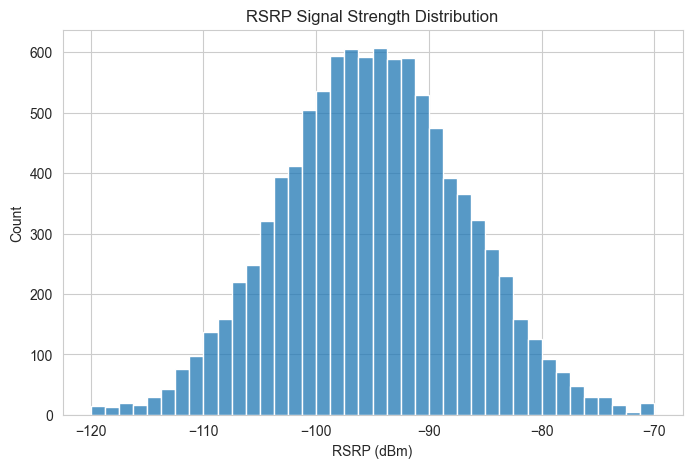

In [4]:
#RSRP Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["rsrp_dbm"], bins=40)

plt.title("RSRP Signal Strength Distribution")
plt.xlabel("RSRP (dBm)")
plt.ylabel("Count")

plt.show()

Most signal strength values range between -100 dBm and -85 dBm,
indicating moderate LTE coverage quality.

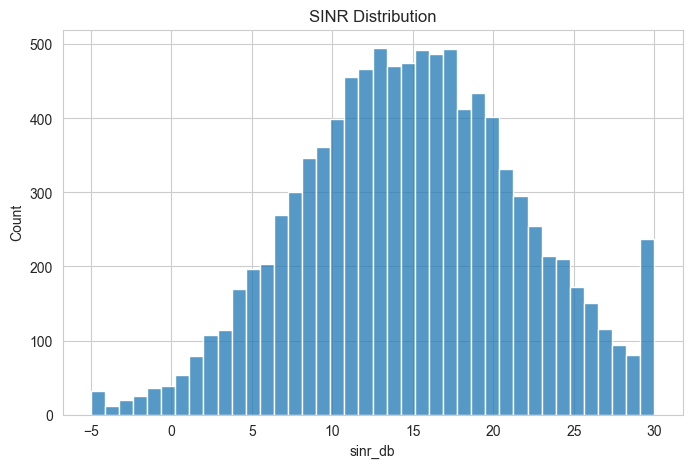

In [5]:
#SINR Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["sinr_db"], bins=40)

plt.title("SINR Distribution")

plt.show()

<h1>SINR vs Throughput (Network Quality)</h1>

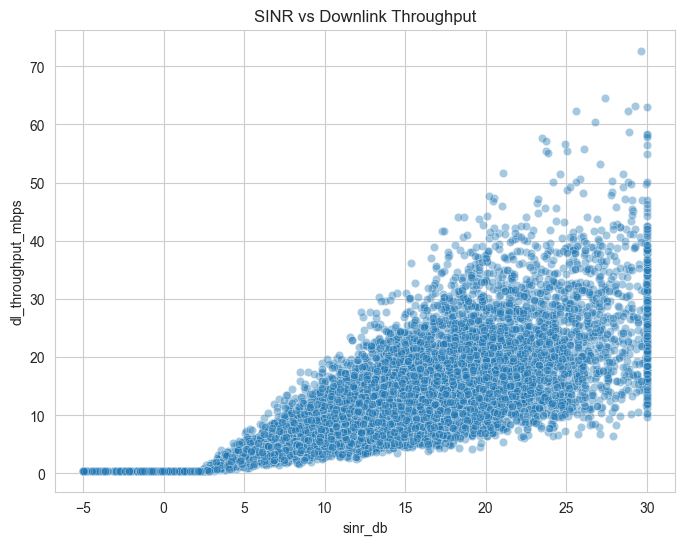

In [6]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="sinr_db",
    y="dl_throughput_mbps",
    alpha=0.4
)

plt.title("SINR vs Downlink Throughput")

plt.show()

Higher SINR values generally correspond to higher throughput,
indicating expected correlation between signal quality and data rate.

<h1>Active Users vs Latency (Congestion)</h1>

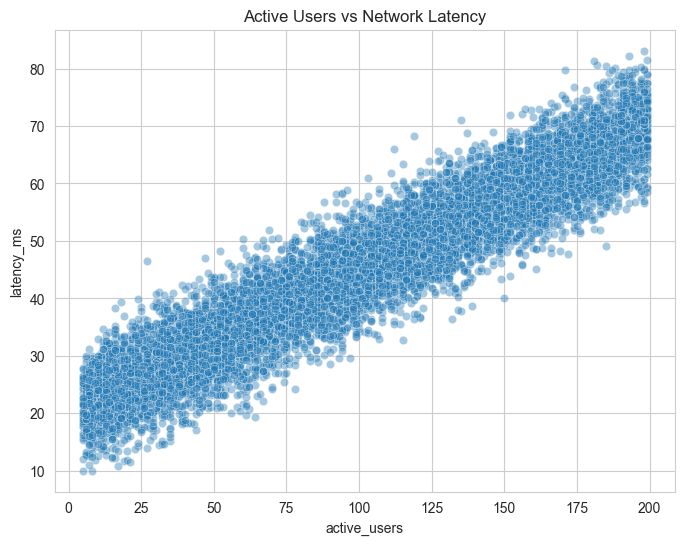

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="active_users",
    y="latency_ms",
    alpha=0.4
)

plt.title("Active Users vs Network Latency")

plt.show()

Latency increases as the number of active users grows,
indicating congestion impact on network performance.

<h1>Operator Performance Comparison</h1>

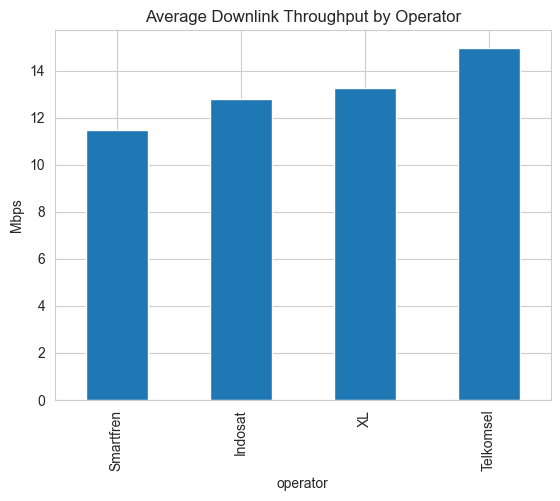

In [8]:
operator_perf = df.groupby("operator")["dl_throughput_mbps"].mean().sort_values()

operator_perf.plot(kind="bar")

plt.title("Average Downlink Throughput by Operator")

plt.ylabel("Mbps")

plt.show()

Telkomsel shows the highest average throughput in this dataset,
while Smartfren shows slightly lower average throughput.

<h1>Regional Network Performance</h1>

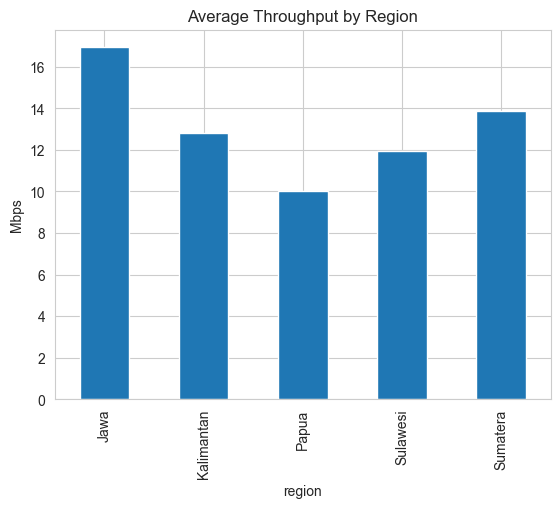

In [9]:
region_perf = df.groupby("region")["dl_throughput_mbps"].mean()

region_perf.plot(kind="bar")

plt.title("Average Throughput by Region")

plt.ylabel("Mbps")

plt.show()

Java region shows the highest throughput due to higher network capacity
and infrastructure density.